In [2]:
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
import polars_random as pr 
import plotly.express as px

## Lecture 4

#### Previously:

In [ ]:
uce = pl.read_csv('data/pivoted-ucb-data-w-everything.csv')

In [9]:
uce = uce.with_columns(app_rate = pl.col('applied')/pl.col('grade_12'))
uce = uce.filter(pl.col('app_rate') < 1)

#### Calculating free/reduced lunch (FLR) percentile and percentile bin columns

Note: we cannot calculate a `frl_percentile` value for a school which has a missing FRL percentage. The code below takes this into account,
                                                  using `.count()` instead of `.len()` in the denominator for the calculation of `frl_percentile_raw`.

- What might be lost when we exclude such schools from our analysis?
- If we had more information, perhaps we could *impute* the FRL values so that we would not have to exclude as many schools.

In [17]:
uce= uce.with_columns(frl_percentile_raw=pl.col('pct_free_reduced').rank()/pl.col('pct_free_reduced').count())

Note: it's worth looking into to *how* `qcut` creates bins. How else might bins be created? What way to create bins is most appropriate for our analysis?

In [ ]:
uce = uce.with_columns(frl_percentile=pl.col('frl_percentile_raw').qcut(4, labels=["0-25", "25-50", "50-75", "75-100"]))

The `filter` is necessary to make sure that schools missing values are not put into a separate bucket.

In [144]:
uce_agged = uce.filter(pl.col('frl_percentile').is_not_null()).group_by('frl_percentile').agg(avg_app_rate=
                                                                                              pl.col('applied').sum()/pl.col('grade_12').sum())

In [145]:
uce_agged

frl_percentile,avg_app_rate
cat,f64
"""50-75""",0.087358
"""0-25""",0.256207
"""75-100""",0.093879
"""25-50""",0.117248


<Axes: xlabel='frl_percentile', ylabel='avg_app_rate'>

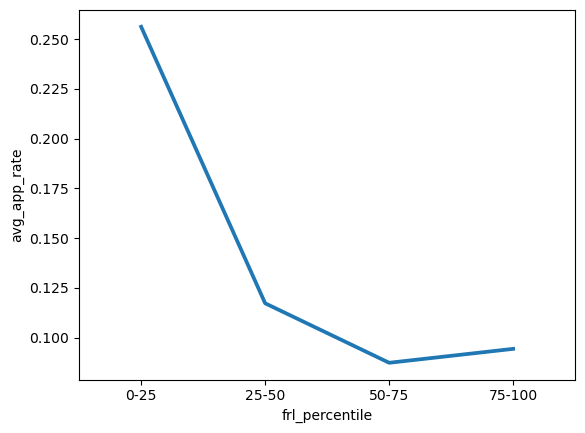

In [217]:
sns.pointplot(uce_agged,x='frl_percentile',y='avg_app_rate',order=["0-25", "25-50", "50-75", "75-100"], marker='')

#### Missing data

We calculate admission rates in four different ways.

##### Ignore `null`s

In [31]:
ignore_null = uce.filter(pl.col('admitted').is_not_null()).group_by('frl_percentile').agg(admission_rate=
                                                                                              pl.col('admitted').sum()/pl.col('applied').sum())

<Axes: xlabel='frl_percentile', ylabel='admission_rate'>

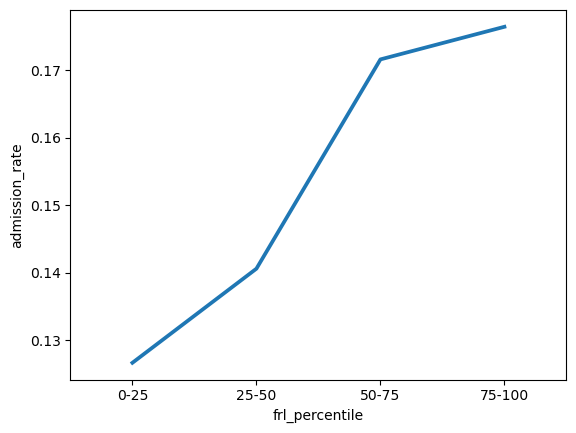

In [32]:
sns.pointplot(ignore_null,x='frl_percentile',y='admission_rate',order=["0-25", "25-50", "50-75", "75-100"], marker='')

##### Replace with 0

In [45]:
replace_0 = uce.with_columns(pl.col("admitted").fill_null(0))

In [46]:
replace_0_grouped = replace_0.group_by('frl_percentile').agg(admission_rate=pl.col('admitted').sum()/pl.col('applied').sum())

<Axes: xlabel='frl_percentile', ylabel='admission_rate'>

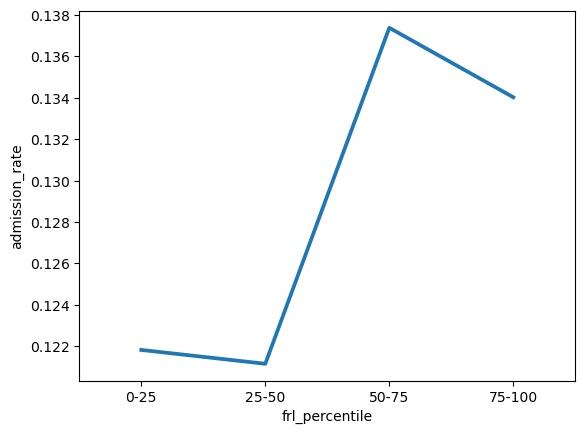

In [47]:
sns.pointplot(replace_0_grouped ,x='frl_percentile',y='admission_rate',order=["0-25", "25-50", "50-75", "75-100"], marker='')

##### Replace with 2

In [48]:
replace_2 = uce.with_columns(pl.col("admitted").fill_null(2))

In [49]:
replace_2_grouped = replace_2.group_by('frl_percentile').agg(admission_rate=pl.col('admitted').sum()/pl.col('applied').sum())

<Axes: xlabel='frl_percentile', ylabel='admission_rate'>

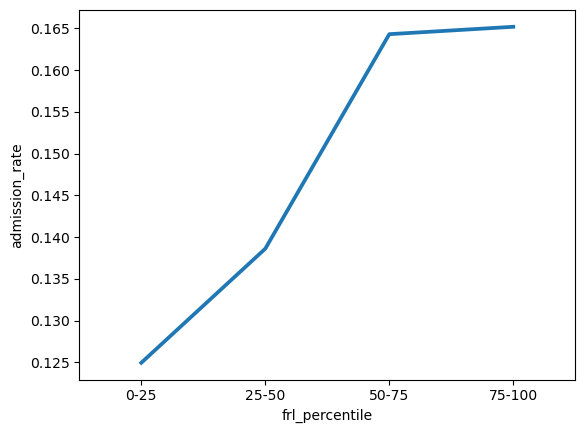

In [51]:
sns.pointplot(replace_2_grouped,x='frl_percentile',y='admission_rate',order=["0-25", "25-50", "50-75", "75-100"], marker='')

##### Replace randomly with 0, 1 or 2

In [73]:
replace_r = uce.with_columns(admitted=pl.when(pl.col("admitted").is_null())
    .then(pr.randint(low=0, high=3,seed=7342))
    .otherwise(pl.col("admitted")))

In [74]:
replace_r_grouped = replace_r.group_by('frl_percentile').agg(admission_rate=pl.col('admitted').sum()/pl.col('applied').sum())

<Axes: xlabel='frl_percentile', ylabel='admission_rate'>

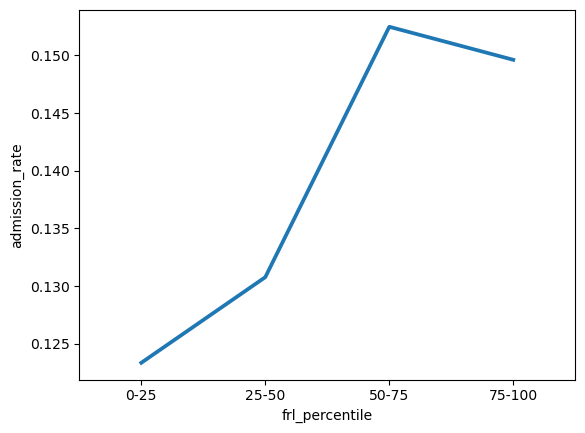

In [75]:
sns.pointplot(replace_r_grouped,x='frl_percentile',y='admission_rate',order=["0-25", "25-50", "50-75", "75-100"], marker='')

In [81]:
uce= uce.with_columns(dist_percentile_raw=pl.col('dist_to_ucb_miles').rank()/pl.col('dist_to_ucb_miles').count())

In [82]:
uce = uce.with_columns(dist_percentile=pl.col('dist_percentile_raw').qcut(4, labels=["0-25", "25-50", "50-75", "75-100"]))

In [94]:
uce_agged_two_groups = uce.filter(pl.col('frl_percentile').is_not_null()).group_by('frl_percentile','dist_percentile').agg(
     applied = pl.col('applied').sum(),
     grade_12 = pl.col('grade_12').sum(),
     app_rate=pl.col('applied').sum()/pl.col('grade_12').sum()).sort('frl_percentile')

In [95]:
uce_agged_two_groups

frl_percentile,dist_percentile,applied,grade_12,app_rate
cat,cat,i64,i64,f64
"""0-25""","""0-25""",15232,45872,0.332054
"""0-25""","""50-75""",4301,15776,0.272629
"""0-25""","""25-50""",2785,20277,0.137348
"""0-25""","""75-100""",8803,39543,0.222618
"""25-50""","""0-25""",4274,27016,0.158203
…,…,…,…,…
"""50-75""","""0-25""",1893,14992,0.126267
"""75-100""","""25-50""",1569,22357,0.070179
"""75-100""","""0-25""",618,4463,0.138472


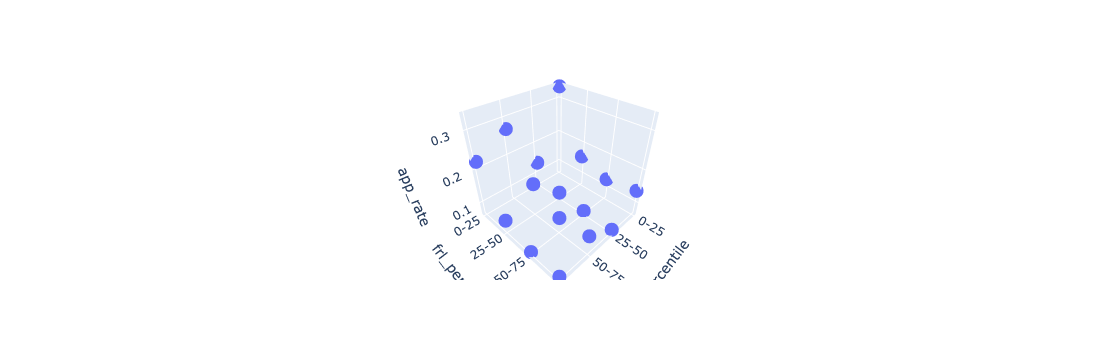

In [106]:
px.scatter_3d(uce_agged_two_groups, x='dist_percentile', y='frl_percentile', z='app_rate',
             category_orders={"dist_percentile": ["0-25", "25-50", "50-75", "75-100"]})

<Axes: xlabel='frl_percentile', ylabel='app_rate'>

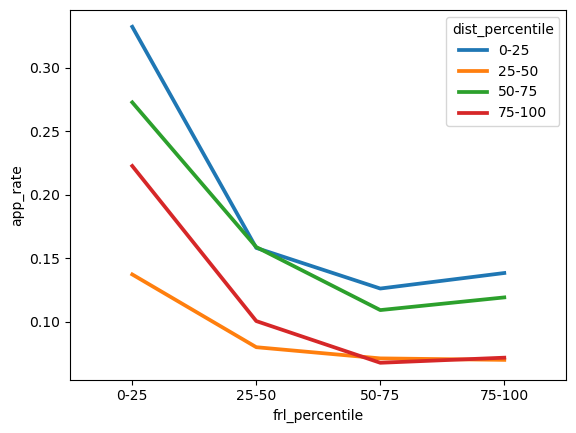

In [114]:
sns.pointplot(uce_agged_two_groups, x='frl_percentile', y='app_rate', hue='dist_percentile', order=["0-25", "25-50", "50-75", "75-100"],
              hue_order=["0-25", "25-50", "50-75", "75-100"],
             marker='')

#### Final recommendation

In [118]:
uce_scatter = uce.filter(pl.col('tot_enrolled') >= 100, 
                       pl.col('is_charter') == 'N').

In [137]:
ordinal = ["1st distance quintile", "2nd distance quintile", "3rd distance quintile", 
                                                        "4th distance quintile", 
                                                        "5th distance quintile"]

In [138]:
uce_scatter = uce_scatter.with_columns(dist_to_ucb_bucket=
            pl.col('dist_to_ucb_miles').qcut(5, labels=ordinal))

In [139]:
uce_scatter = uce_scatter.filter(pl.col('pct_free_reduced').is_not_null()).filter(pl.col('app_rate').is_not_null())

In [140]:
uce_scatter = uce_scatter.with_columns(dist_to_ucb_bucket = pl.col('dist_to_ucb_bucket').cast(pl.Enum(ordinal)))

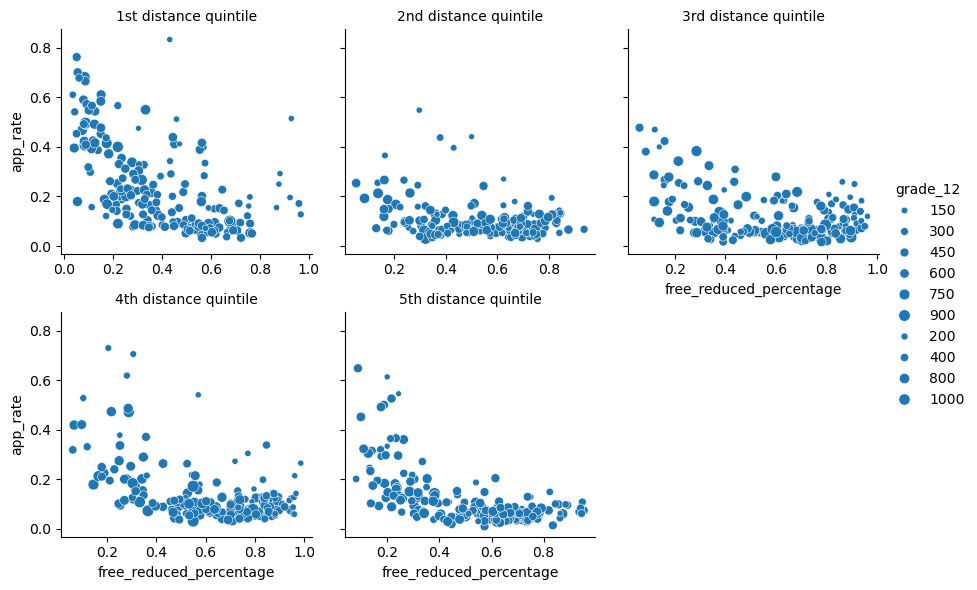

In [141]:
g = sns.FacetGrid(uce_scatter, col="dist_to_ucb_bucket", col_wrap=3, sharex=False)
g.map_dataframe(sns.scatterplot, x="pct_free_reduced", y="app_rate", size="grade_12")
g.set_axis_labels("free_reduced_percentage", "app_rate")
g.set_titles(col_template="{col_name}")
g.add_legend(title="grade_12")